In [ ]:
import marimo as mo

# Feed-forward neural networks

*August 4 2026*
*Training Workshop: Introduction to Deep Graph Learning*
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*

Starting from the simple perceptron model implemented in the previous notebook, we now create a model that consists of multiple layers of perceptrons. While a single-layer perceptron model can only learn linear decision boundaries, we can use multi-layer generalizations to learn arbitrary patterns (based on the ability of multi-layer neural networks to approximate any continuous function). Building on what we learned in the previous notebook, we will implement our model in pytorch, using stochastic gradient descent and automatic gradient computation via backpropagation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import torch
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from torch.autograd import Variable

import pathpyG as pp

np.set_printoptions(precision=4)
plt.style.use('default')
sns.set_style("whitegrid")

In the previous notebooks, we used a maximally simple data set with (i) a single input feature and (ii) a very simple pattern that allowed classes to be separated by a simple perceptron model. Let us now consider an example with two features $x$ and $y$ and a pattern that requires a non-linear decision boundary. We will show that a multi-layer perceptron model is able to learn this decision boundary.

To generate this data set, we use the function `make_circles` in `sklearn.datasets`.

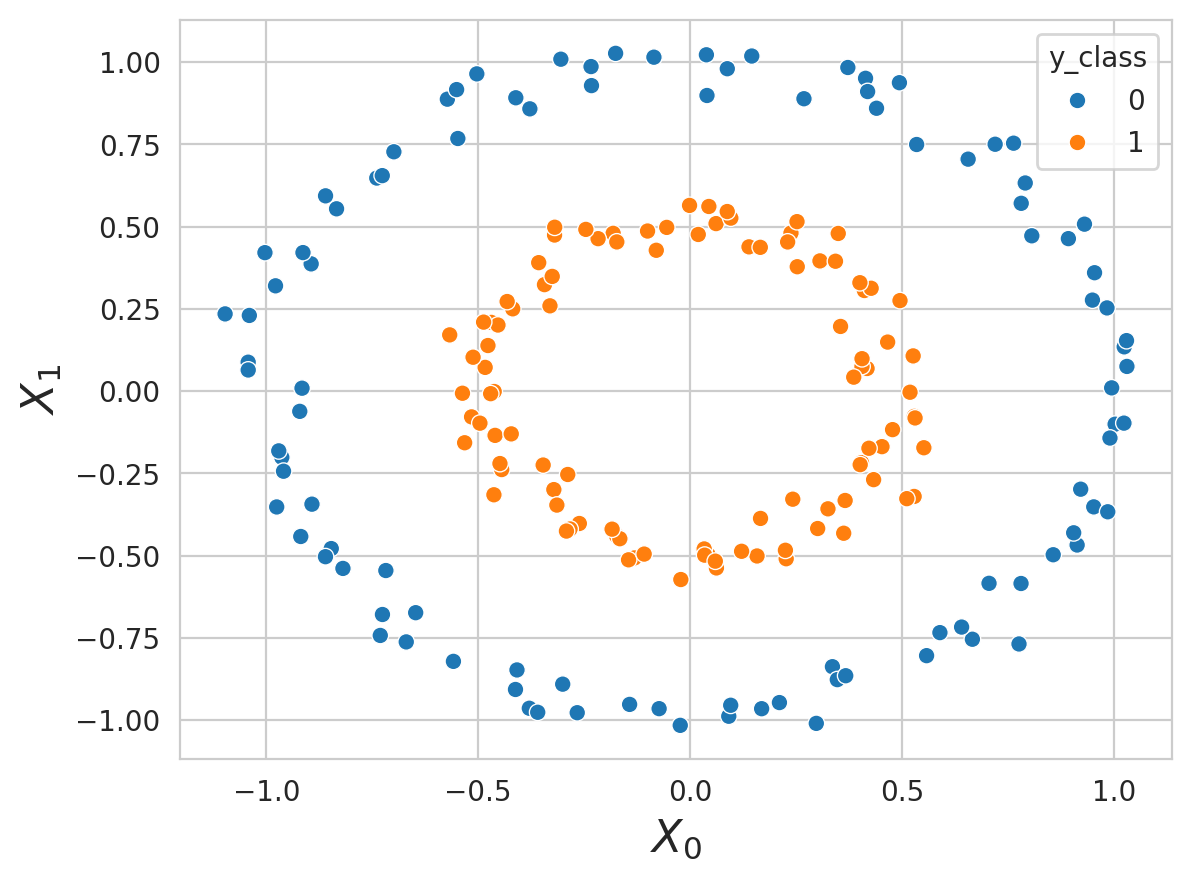

In [ ]:
_x, c = make_circles(n_samples=200, noise=0.05, factor=0.5)
data = pd.DataFrame({'x0': _x[:, 0], 'x1': _x[:, 1], 'y_class': c})
sns.scatterplot(x='x0', y='x1', data=data, hue='y_class')
plt.xlabel('$X_0$', fontsize=16)
plt.ylabel('$X_1$', fontsize=16)

We can further use `sklearn` functions to generate a train-test split of our data set:

In [ ]:
train, test = train_test_split(data, train_size=0.8)

In [ ]:
train_features = train[['x0', 'x1']]
train_labels = train[['y_class']]

print("\nTraining features:")
print(train_features.values[:5])
print("\nTraining class labels: ")
print(train_labels.values[:5])


Training features:
[[-0.1004  0.4868]
 [ 0.4014 -0.2234]
 [ 0.2423 -0.3284]
 [ 0.4141  0.9511]
 [-0.7259 -0.679 ]]

Training class labels: 
[[1]
 [1]
 [1]
 [0]
 [0]]


In [ ]:
train_features_1 = torch.tensor(train_features.values, dtype=torch.float32)
train_labels_1 = torch.tensor(train_labels.values, dtype=torch.float32)

In [ ]:
class Perceptron(torch.nn.Module):
    """A single-layer perceptron model."""

    def __init__(self):
        """Initialize the model parameters."""
        super(Perceptron, self).__init__()
        self.linear = torch.nn.Linear(in_features=2, out_features=1, bias=True)
    
    def forward(self, x):
        """Compute the output of the perceptron."""
        # we use a logistic transformation to output class probabilities        
        return torch.special.expit(self.linear(x))

# create perceptron and configure learning process
model = Perceptron()

# we use the mean absolute diff between target and prediction as loss function
loss_func = torch.nn.MSELoss()

# the number of epochs gives the number of times we run the 
# optimization algorithm on all examples in our training set
epochs = 100

# the learning rate controls how much parameters are 
# changed (based on the gradients) for each training sample
learning_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
model.train()
errors = []
for _epoch in range(epochs):
    _error = 0
    for _i in range(len(train_features_1)):
        _x = train_features_1[_i].reshape(2)
        label = train_labels_1[_i].reshape(1)
        optimizer.zero_grad()
        _output = model(_x)
        _loss = loss_func(_output, label)
        _loss.backward()
        optimizer.step()
        _error = _error + _loss
    errors.append(_error.detach().numpy())
plt.plot(range(epochs), errors)
print('bias =', model.linear.bias.data)
print('weight =', model.linear.weight.data)

bias = tensor([0.0755])
weight = tensor([[ 0.0665, -0.1597]])


In [ ]:
def predict(prob):
    """Dichotomize a class probability based on a threshold of 0.5."""
    if prob>=0.5:
        return 1
    else:
        return 0

/tmp/marimo_536335/__marimo__cell_Hstk_.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  test['predicted'] = [predict(x) for x in model(torch.from_numpy(test[['x0', 'x1']].values).float()).detach().numpy()]


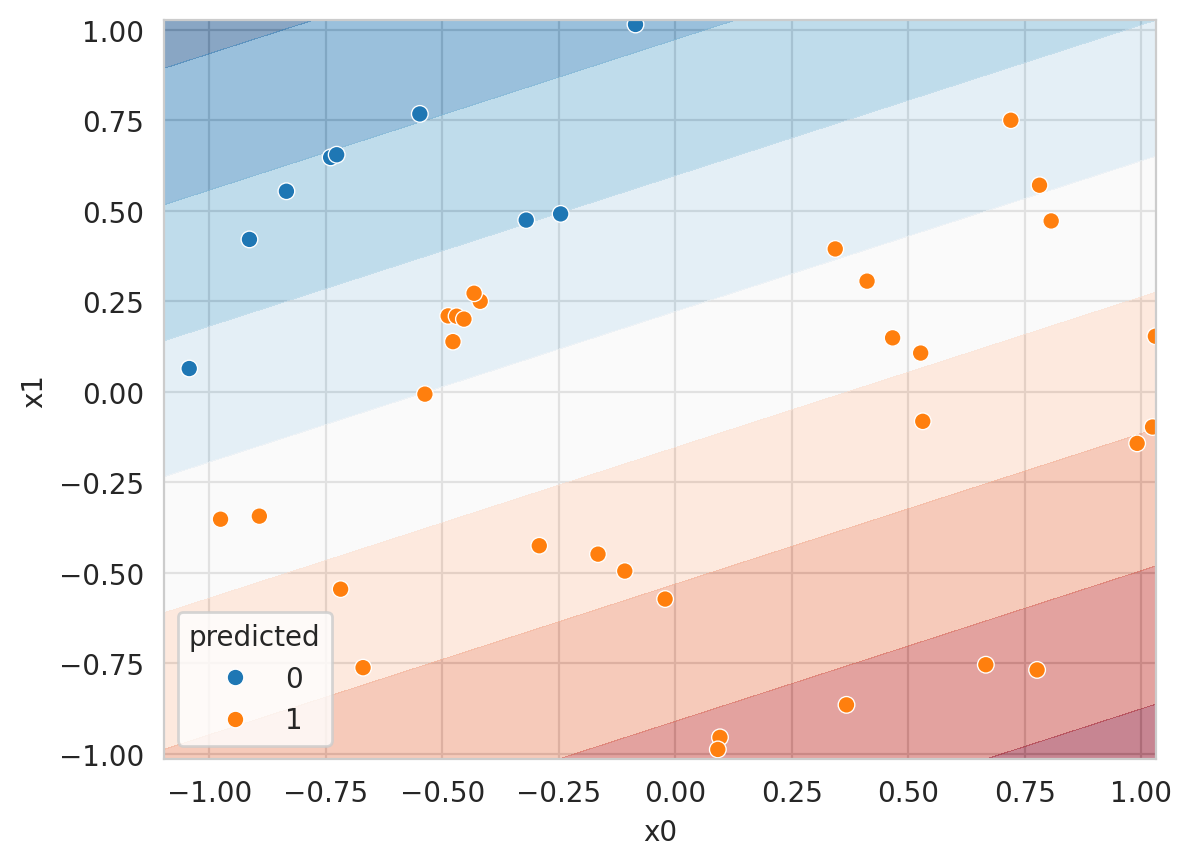

In [ ]:
_min_x = data['x0'].min()
_min_y = data['x1'].min()
_max_x = data['x0'].max()
_max_y = data['x1'].max()
_x_mesh, _y_mesh = np.meshgrid(np.linspace(_min_x, _max_x, 100), np.linspace(_min_y, _max_y, 100))
_class_probs = model(Variable(torch.from_numpy(np.c_[_x_mesh.ravel(), _y_mesh.ravel()]).float()))
_z = np.array(_class_probs.detach().numpy()).reshape(_x_mesh.shape)
test['predicted'] = [predict(x) for x in model(torch.from_numpy(test[['x0', 'x1']].values).float()).detach().numpy()]
#print(logits)
_fig, _ax = plt.subplots()
#probs = torch.softmax(logits, dim=0)
_ax.contourf(_x_mesh, _y_mesh, _z, cmap='RdBu_r', alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=test, hue='predicted')

## Feed-forward neural networks

Building on the lecture, we now implement a feed-forward neural network that consists of three layers, where all "neurons" in one layer are connected to each "neuron" in the subsequent layer.

1) The input layer consists of two inputs that represent the two features in our data. Each of those inputs is fed into each perceptron in the hidden layer. Note that the nodes in the input layer are actually not perceptrons. They are just nodes that represent the input variables, which is why our model actually only has two layers of perceptrons (and associated weight parameters).

2) The hidden layer consists of multiple perceptrons, where each perceptron receives all inputs and generates a single output (calculated based on a linear combination and a and an activation function) that is forwarded to each of the output nodes.

3) The output layer consists of (possibly) multiple perceptrons, where each perceptron receives all outputs of the hidden layer as input, generating one output variable. In our example of a binary classifier, we only have a single output variable and thus only a single perceptron in the output layer.

We see that this architecture actually consists of one input layer as well as two layers of perceptrons, for which we can use the `torch.nn.Linear` class. We implement this in the following `torch` module.

In the function `forward` we first pass the input features to the hidden layer. We apply a non-linear activation function to the linearly transformed inputs, which generates the output of the hidden layer. We then pass this as input to the second layer. We can choose the number of hidden neurons in the hidden layer, which is independent both from the dimensions of the input and the number of output variables.

In [ ]:
class FFNet(torch.nn.Module):
    """A feed-forward neural network with a single hidden layer."""

    def __init__(self, in_ch, hidden_dim, out_ch):        
        """Initialize the model parameters."""
        super(FFNet, self).__init__()

        # each of the two layers applies a linear transformation y = x A^T + b to its input variables x, 
        # where b is bias, and y is output

        # A is a matrix that captures the weights of connections (i.e. the slope of the linear model) of the input variables

        # this generates hidden_dim perceptrons, each receiving in_ch inputs
        self.in2hidden = torch.nn.Linear(in_features=in_ch, out_features=hidden_dim, bias=True)

        # this generates out_ch perceptrons, each receiving hidden_dim inputs
        self.hidden2out = torch.nn.Linear(in_features=hidden_dim, out_features=out_ch, bias=True)

    def forward(self, x):        
        """Compute the output of the network."""
        hidden = self.in2hidden(x)

        # we can use different non-linear activation functions. Here we use the
        # sigmoid function, which maps to an output from 0 to 1 that can be interpreted
        # as class probability (analogous to the logistic function in logistic regression)
        hidden = torch.sigmoid(hidden)

        # we pass this as input to the output layer
        output = self.hidden2out(hidden)

        # we finally apply a sigmoid activation function, which yields a single 
        # output that can be interpreted as class probability
        output = torch.sigmoid(output)

        return output

To test our (untrained) model, we can pass the features of a single data point.

In [ ]:
model_1 = FFNet(in_ch=2, hidden_dim=6, out_ch=1)
_x = train_features_1[0].reshape(1, 2)
model_1.forward(_x)

tensor([[0.6213]], grad_fn=<SigmoidBackward0>)

We can now train our model. Following the previous notebook, for this we need:

1) A loss function to evaluate the current performance of our model. Note that the loss function must be chosen such that it fits the output of our model. Here, by using the sigmoid activation function and a single output variable, our model outputs the probability of a class (e.g. class 1). Here, we can use the binary cross entropy loss function, which

2) Gradients of all our model parameters, which are automatically calculated by the `autograd` module when we backpropagate the loss function

3) An optimization algorithm that uses those gradients to optimize the model parameters. Here we will again use the Stochastic Gradient Descent implementation included in `pytorch`.

In [ ]:
epochs_1 = 100
_lrn_rate = 0.1
loss_func_1 = torch.nn.MSELoss()
optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=_lrn_rate)

In [ ]:
print('\nStarting training ')
model_1.train()
_indices = np.arange(160)
losses = []
for _epoch in range(epochs_1):
    _error = 0
    np.random.shuffle(_indices)
    for _i in _indices:
        _X = train_features_1[_i].reshape(1, 2)
        _Y = train_labels_1[_i]
        optimizer_1.zero_grad()
        _output = model_1(_X)
        _loss = loss_func_1(_output[0], _Y)
        _loss.backward()
        _error = _error + _loss.detach().numpy()
        optimizer_1.step()
    losses.append(_error)
print('Finished training.')


Starting training 
Finished training.


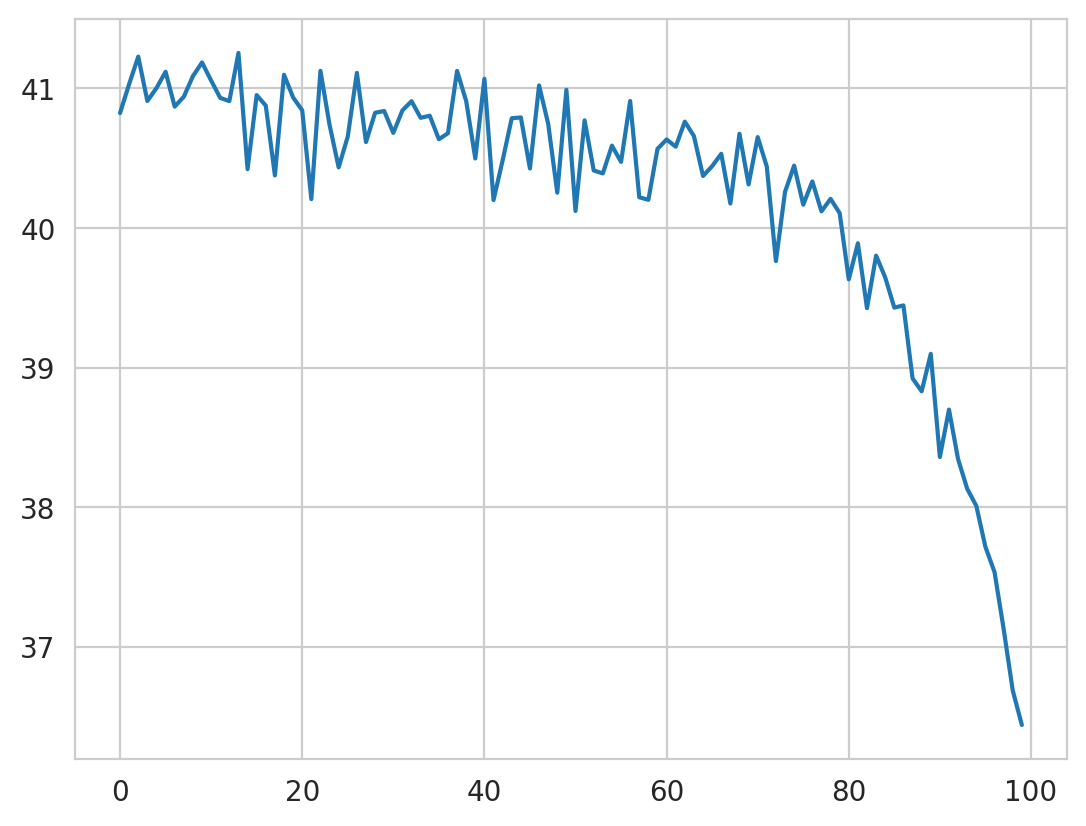

In [ ]:
plt.plot(range(epochs_1), losses)

In [ ]:
def predict_1(prob):
    """Dichotomize a class probability based on a threshold of 0.5."""
    if prob > 0.5:
        return 1
    else:
        return 0

In [ ]:
# Set network to evaluation mode
model_1.eval()
feature = test[['x0', 'x1']].values[0]
print('\nPredicting class for: ', feature)
t = torch.tensor(feature, dtype=torch.float32)
class_prob = model_1(t)
print(class_prob)
# create tensor
print(predict_1(class_prob.detach().numpy()[0]))
#print(logits.detach().numpy())
# softmax = multinomial generalization of logistic function / normalizes output to probabilities
#probs = torch.softmax(logits, dim=0)
# detach tensor from neural net (possibly copying it to the CPU)
#probs = probs.detach().numpy()
print(test['y_class'].values[0])


Predicting class for:  [0.3431 0.395 ]
tensor([0.5484], grad_fn=<SigmoidBackward0>)
1
1


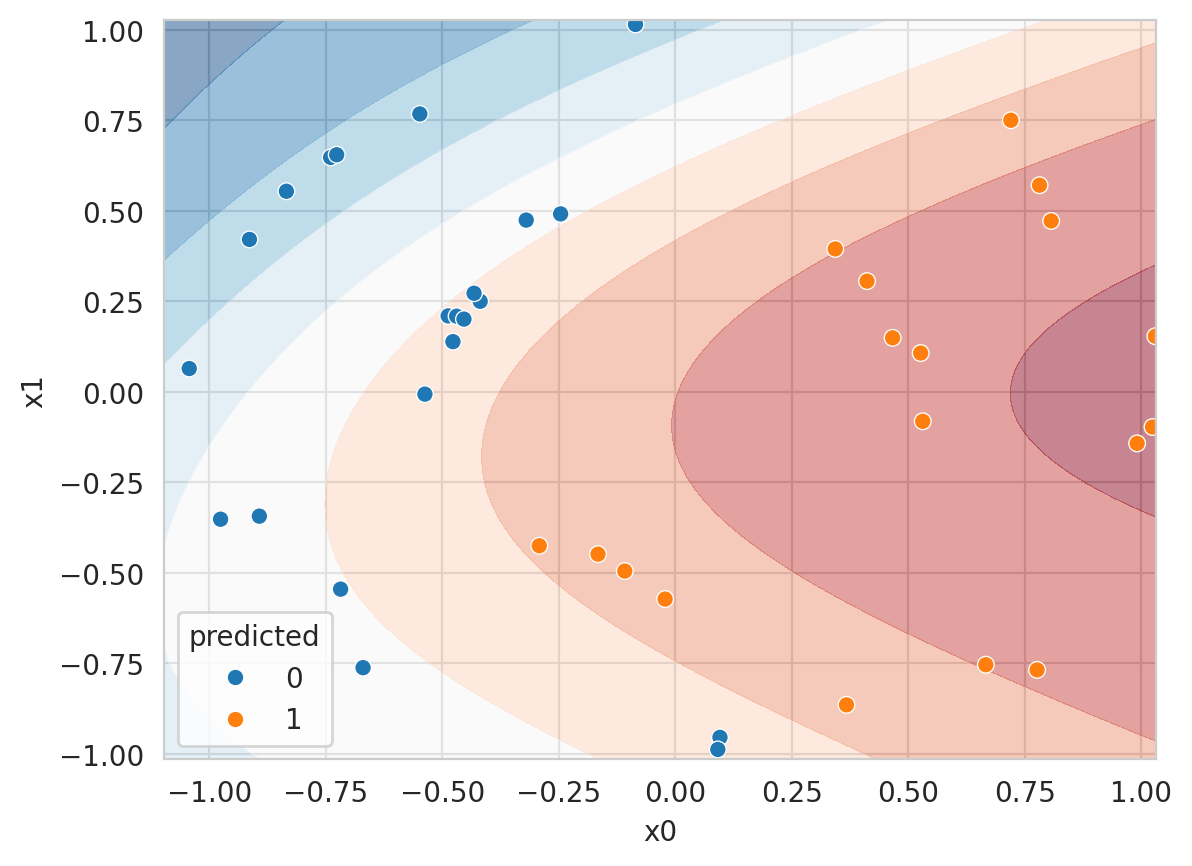

In [ ]:
_min_x = data['x0'].min()
_min_y = data['x1'].min()
_max_x = data['x0'].max()
_max_y = data['x1'].max()
_x_mesh, _y_mesh = np.meshgrid(np.linspace(_min_x, _max_x, 100), np.linspace(_min_y, _max_y, 100))
_class_probs = model_1(Variable(torch.from_numpy(np.c_[_x_mesh.ravel(), _y_mesh.ravel()]).float()))
_z = np.array(_class_probs.detach().numpy()).reshape(_x_mesh.shape)
test['predicted'] = [predict_1(x) for x in model_1(torch.from_numpy(test[['x0', 'x1']].values).float()).detach().numpy()]
_fig, _ax = plt.subplots()
_ax.contourf(_x_mesh, _y_mesh, _z, cmap='RdBu_r', alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=test, hue='predicted')

## Non-Linear Node Classification with Neural Networks

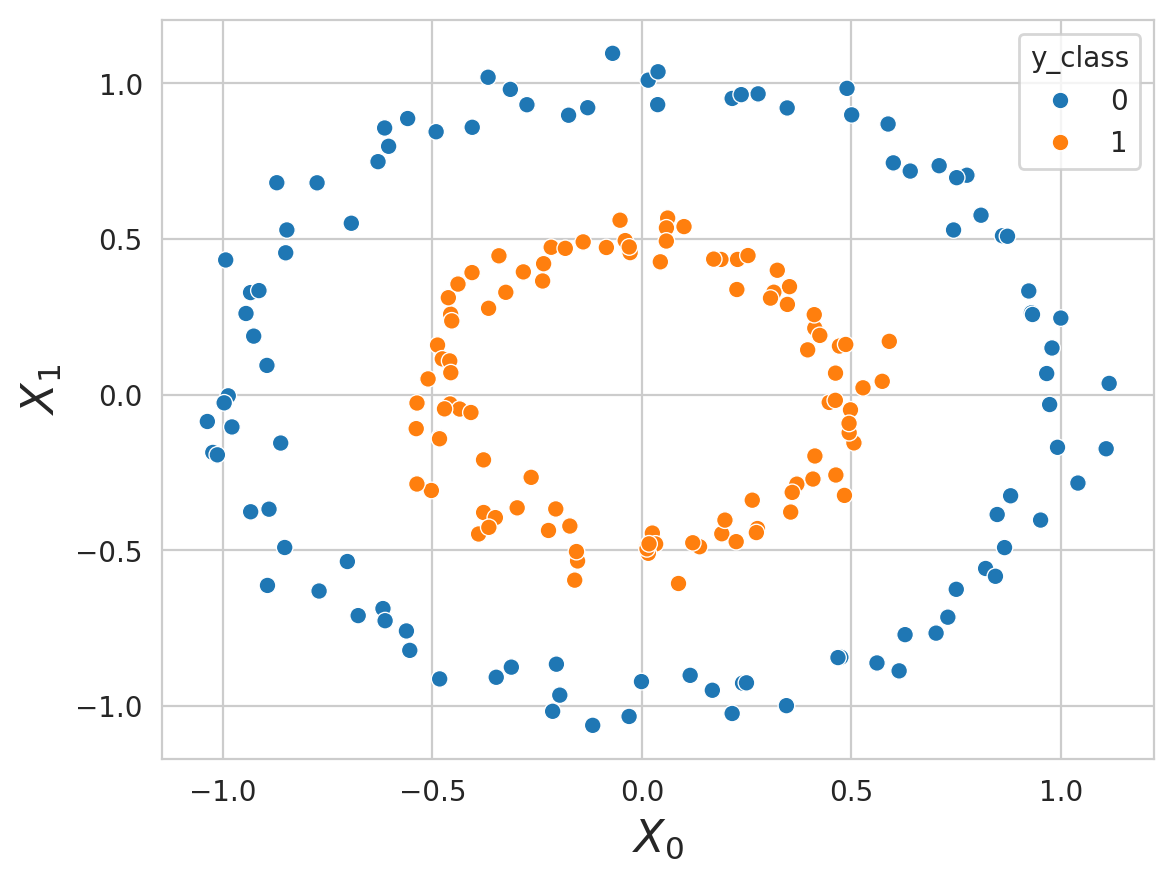

In [ ]:
_x, c_1 = make_circles(n_samples=200, noise=0.05, factor=0.5)
data_1 = pd.DataFrame({'x0': _x[:, 0], 'x1': _x[:, 1], 'y_class': c_1})
sns.scatterplot(x='x0', y='x1', data=data_1, hue='y_class')
plt.xlabel('$X_0$', fontsize=16)
plt.ylabel('$X_1$', fontsize=16)

In [ ]:
def euclidean_dist(x, y):
    """Return the Euclidean distance between two points."""
    return np.linalg.norm(x-y)

def soft_rule(dist, **kwargs):
    """Randomly decide whether to connect two nodes at the given distance."""
    p = kwargs['beta'] * np.exp(-dist/kwargs['alpha'])
    if np.random.random() <= p:
        return True
    else:
        return False

In [ ]:
node_ids = [str(i) for i in range(len(data_1))]
pos = {str(i): np.array([row['x0'], row['x1']]) for i, row in data_1.iterrows()}
edges = []
for _v in node_ids:
    for w in node_ids:
        if soft_rule(euclidean_dist(pos[_v], pos[w]), alpha=0.05, beta=50) and _v != w:
            edges.append((_v, w))
net = pp.Graph.from_edge_list(edges, mapping=pp.IndexMap(node_ids)).to_undirected()
print(net)

Undirected graph with 200 nodes and 1193 edges
{'Edge Attributes': {}, 'Graph Attributes': {'num_nodes': "<class 'int'>"}, 'Node Attributes': {}}


In [ ]:
colors = {}
colors[0] = 'orange'
colors[1] = 'CornflowerBlue'
g_class = {str(i): c_1[i] for i in range(len(data_1))}
node_colors = {v: colors[g_class[v]] for v in net.nodes}
pp.plot(net, edge_color='grey', node_color=node_colors)

<pathpyG.visualisations._d3js.backend.D3jsBackend object at 0x7e7515043e00>

In [ ]:
nodes = [(v, g_class[v]) for v in net.nodes]
data_2 = pd.DataFrame(nodes, columns=['v', 'g'])
train_1, test_1 = train_test_split(data_2, test_size=0.3)

In [ ]:
def laplacian(network):
    """Return the Laplacian matrix of a network."""
    A = network.sparse_adj_matrix()
    D = sp.sparse.diags(network.degrees(mode='in', return_tensor=True).numpy())
    L = D - A
    return L

def normalized_laplacian(network: pp.Graph):
    """Return the normalized Laplacian matrix of a network."""
    identity = sp.sparse.identity(network.n)
    A = network.sparse_adj_matrix()
    D_inv_sqrt = sp.sparse.diags(network.degrees(mode='in', return_tensor=True).numpy()).power(-0.5)
    L = identity - D_inv_sqrt * A * D_inv_sqrt
    return L

def laplacian_embedding(network, laplacian, d=None):
    """Return a vector representation of all nodes based on the entries of eigenvectors of the laplacian."""
    if d is None:
        d = network.n - 1
    ew, ev = sp.linalg.eig(laplacian.todense())
    index = np.argsort(ew)[1:]
    ev = ev[:, index]
    ew = ew[index]  # get eigenvectors and eigenvalues in ascending order, skipping the first
    vecs = {}
    for v in network.nodes:
        idx = network.mapping.to_idx(v)
        vecs[v] = ev[idx, :d].real
        for i in range(d):  #ev = normalize(ev, p=2)
            vecs[v][i] = vecs[v][i] / ew[i].real
    return vecs

def assign_features(embedding, df):  # embedding x_ of node i in m-dimensional vector space is given by 
    """Add the embedding coordinates of each node as feature columns of a data frame."""  # i-th component in the first m eigenvectors 
    for index, row in df.iterrows():  # (ignoring the eigenvector corrresponding to zero eigenvalue)
        f = embedding[row['v']]  #embedding = ev[:,:d]
        for i in range(len(f)):
            df.loc[index, 'x{0}'.format(i)] = f[i]  #vecs[v] = np.squeeze(np.asarray(ev[network.nodes.index[v],1:d+1].real))

In [ ]:
embedding = laplacian_embedding(net, laplacian(net), d=2)
assign_features(embedding, train_1)
assign_features(embedding, test_1)
assign_features(embedding, data_2)

/tmp/marimo_536335/__marimo__cell_NCOB_.py:4: FutureWarning: Input has data type int32, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sp.sparse.diags(network.degrees(mode='in', return_tensor=True).numpy())


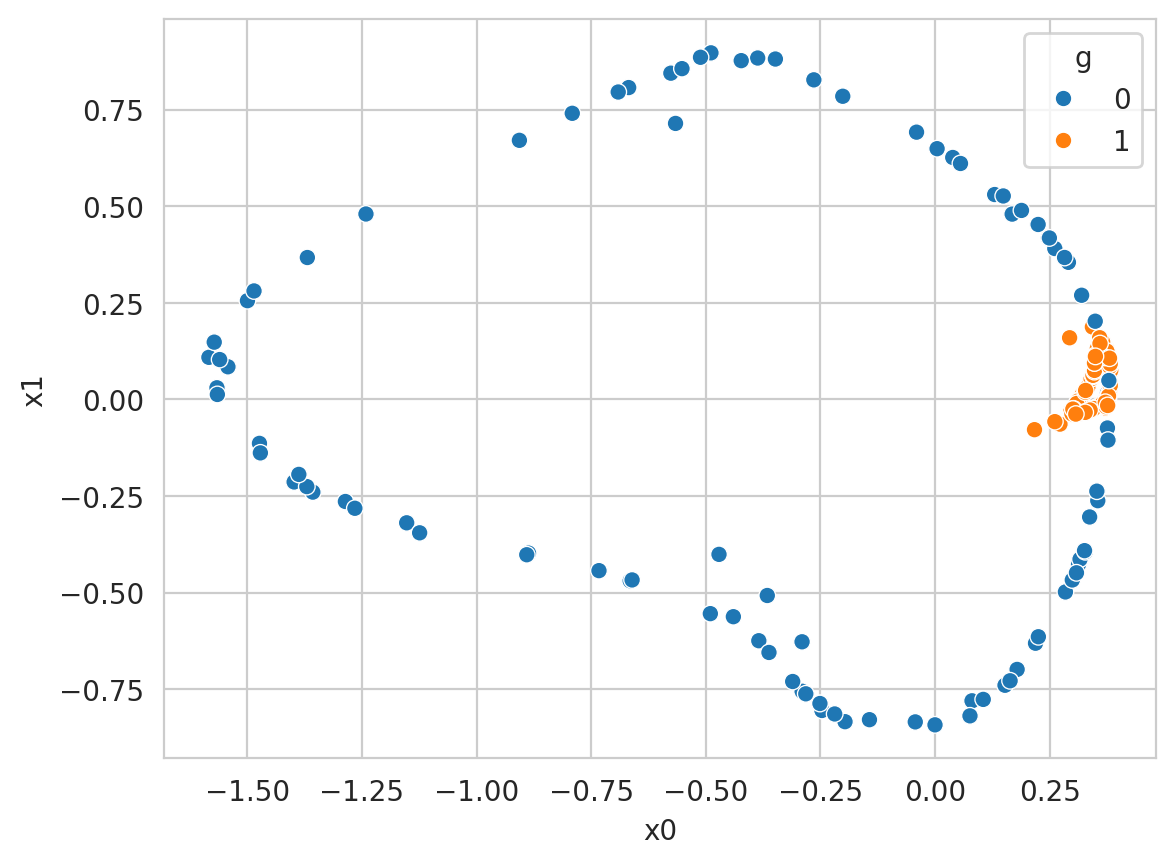

In [ ]:
sns.scatterplot(data=data_2, x='x0', y='x1', hue='g')

In [ ]:
train_features_2 = train_1[['x0', 'x1']]
train_labels_2 = train_1[['g']]
train_features_2 = torch.tensor(train_features_2.values, dtype=torch.float32)
train_labels_2 = torch.tensor(train_labels_2.values, dtype=torch.float32)

In [ ]:
model_2 = FFNet(in_ch=2, hidden_dim=6, out_ch=1)
epochs_2 = 500
_lrn_rate = 0.1
loss_func_2 = torch.nn.MSELoss()
optimizer_2 = torch.optim.SGD(model_2.parameters(), lr=_lrn_rate)

In [ ]:
print('\nStarting training ')
model_2.train()
_indices = np.arange(len(train_features_2))
losses_1 = []
for _epoch in range(epochs_2):
    _error = 0
    np.random.shuffle(_indices)
    for _i in _indices:
        _X = train_features_2[_i].reshape(1, 2)
        _Y = train_labels_2[_i]
        optimizer_2.zero_grad()
        _output = model_2(_X)
        _loss = loss_func_2(_output[0], _Y)
        _loss.backward()
        _error = _error + _loss.detach().numpy()
        optimizer_2.step()
    losses_1.append(_error)
print('Done training ')


Starting training 
Done training 


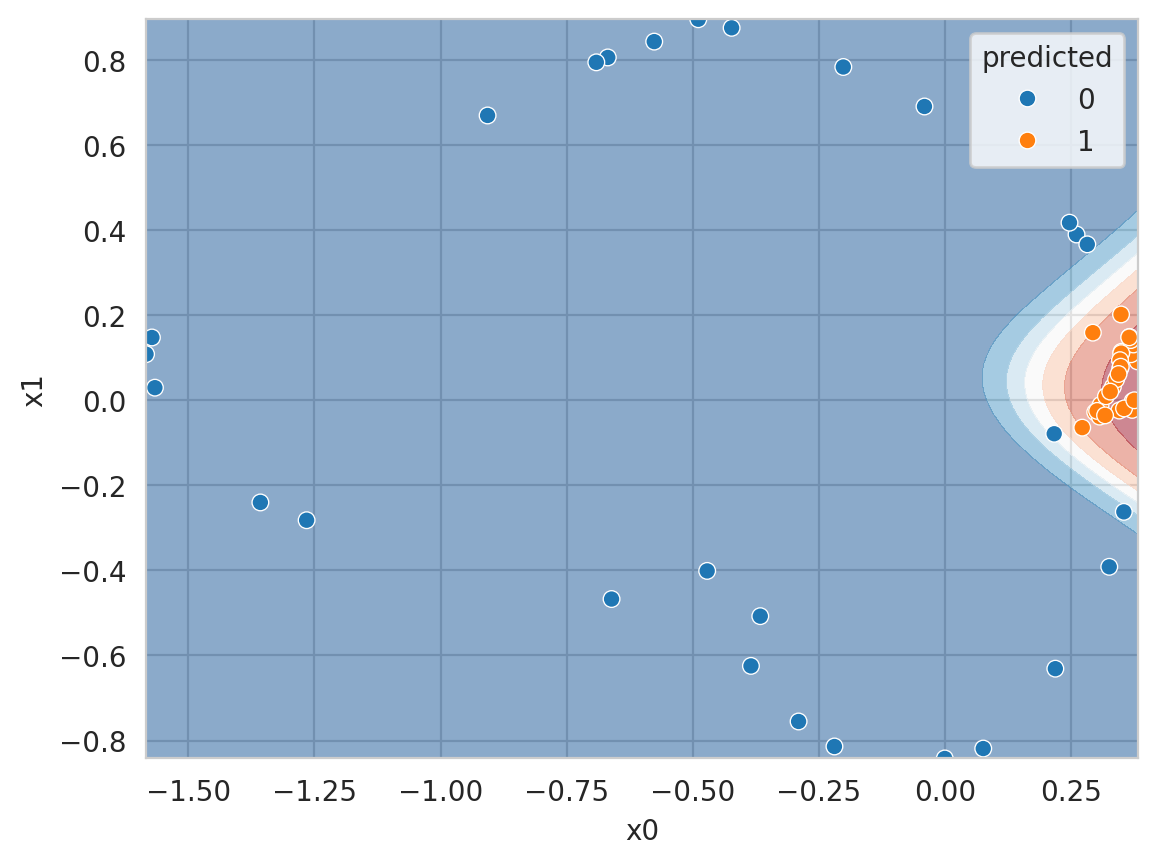

In [ ]:
_min_x = data_2['x0'].min()
_min_y = data_2['x1'].min()
_max_x = data_2['x0'].max()
_max_y = data_2['x1'].max()
_x_mesh, _y_mesh = np.meshgrid(np.linspace(_min_x, _max_x, 100), np.linspace(_min_y, _max_y, 100))
_class_probs = model_2(Variable(torch.from_numpy(np.c_[_x_mesh.ravel(), _y_mesh.ravel()]).float()))
_z = np.array(_class_probs.detach().numpy()).reshape(_x_mesh.shape)
test_1['predicted'] = [predict_1(x) for x in model_2(torch.from_numpy(test_1[['x0', 'x1']].values).float()).detach().numpy()]
_fig, _ax = plt.subplots()
_ax.contourf(_x_mesh, _y_mesh, _z, cmap='RdBu_r', alpha=0.5)
sns.scatterplot(x='x0', y='x1', data=test_1, hue='predicted')

In [ ]:
train_nodes = set([x for x in train_1['v'].values])
test_nodes = set([x for x in test_1['v'].values])
node_colors_1 = {}
for _v in net.nodes:
    if _v in train_nodes:
        node_colors_1[_v] = 'grey'
    else:
        node_colors_1[_v] = colors[int(test_1[test_1['v'] == _v]['predicted'].iloc[0])]

In [ ]:
pp.plot(net, edge_color='grey', node_color=node_colors_1)

<pathpyG.visualisations._d3js.backend.D3jsBackend object at 0x7e7514f8a5d0>